# 1. Business Problem

The previous iFood's marketing campaign had a low response rate and generated negative profit.  
The goal of this project is to help iFood improve the next direct marketing campaign by:

1. Understanding customer characteristics and behavior
2. Segmenting customers into meaningful business groups
3. Building a classification model to predict campaign response
4. Recommending a profit-based targeting strategy

Main business question:

How can iFood identify the customers most likely to respond to the next campaign and improve campaign profitability?

In [19]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

sns.set(style="whitegrid")

In [1]:
from google.colab import files
uploaded = files.upload()

Saving ifood_df.csv to ifood_df (1).csv


In [3]:
df = pd.read_csv("ifood_df.csv")

In [5]:
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


In [6]:
df.shape

(2205, 39)

In [7]:
df.columns

Index(['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Customer_Days', 'marital_Divorced', 'marital_Married',
       'marital_Single', 'marital_Together', 'marital_Widow',
       'education_2n Cycle', 'education_Basic', 'education_Graduation',
       'education_Master', 'education_PhD', 'MntTotal', 'MntRegularProds',
       'AcceptedCmpOverall'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3         

In [9]:
df.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000
mean,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,...,0.257596,0.034467,0.089796,0.024490,0.504762,0.165079,0.215873,562.764626,518.707483,0.29932
std,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,...,0.437410,0.182467,0.285954,0.154599,0.500091,0.371336,0.411520,575.936911,553.847248,0.68044
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.00000
25%,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,42.000000,0.00000
50%,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.00000
75%,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,884.000000,0.00000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.00000


## Data Overview Insight

The dataset contains customer demographic information, purchase behavior, campaign history, and the target variable `Response`, which indicates whether a customer accepted the last campaign offer.

Data Cleaning

In [20]:
df.isnull().sum().sort_values(ascending=False)

,0
Income,0
Kidhome,0
Teenhome,0
Recency,0
MntWines,0
MntFruits,0
MntMeatProducts,0
MntFishProducts,0
MntSweetProducts,0
MntGoldProds,0


In [22]:
# Check duplicate rows

df.duplicated().sum()

np.int64(184)

In [23]:
# Remove duplicates if any

df = df.drop_duplicates()

In [25]:
# Convert DtCustomer to datetime

# df['DtCustomer'] = pd.to_datetime(df['DtCustomer'], errors='coerce')

In [26]:
# Check cleaned data

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2021 entries, 0 to 2204
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2021 non-null   float64
 1   Kidhome               2021 non-null   int64  
 2   Teenhome              2021 non-null   int64  
 3   Recency               2021 non-null   int64  
 4   MntWines              2021 non-null   int64  
 5   MntFruits             2021 non-null   int64  
 6   MntMeatProducts       2021 non-null   int64  
 7   MntFishProducts       2021 non-null   int64  
 8   MntSweetProducts      2021 non-null   int64  
 9   MntGoldProds          2021 non-null   int64  
 10  NumDealsPurchases     2021 non-null   int64  
 11  NumWebPurchases       2021 non-null   int64  
 12  NumCatalogPurchases   2021 non-null   int64  
 13  NumStorePurchases     2021 non-null   int64  
 14  NumWebVisitsMonth     2021 non-null   int64  
 15  AcceptedCmp3          2021

Summary: The dataset given is clean and ready for further anaysis

1. **Data Exploration**

Response Distribution

In [27]:
# Response count

response_counts = df['Response'].value_counts()
response_rate = df['Response'].mean()

response_counts, response_rate

(Response
 0    1710
 1     311
 Name: count, dtype: int64,
 np.float64(0.15388421573478475))

How many customers accepted vs rejected the campaign?

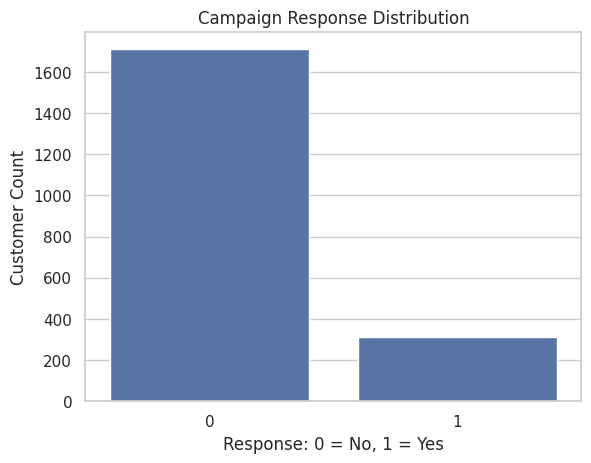

In [28]:
sns.countplot(x='Response', data=df)
plt.title("Campaign Response Distribution")
plt.xlabel("Response: 0 = No, 1 = Yes")
plt.ylabel("Customer Count")
plt.show()

## Business Insight

The response rate is low, meaning most customers did not accept the campaign offer.  
This suggests that mass targeting is inefficient and that iFood needs a more selective targeting strategy.

#Income Vs Response

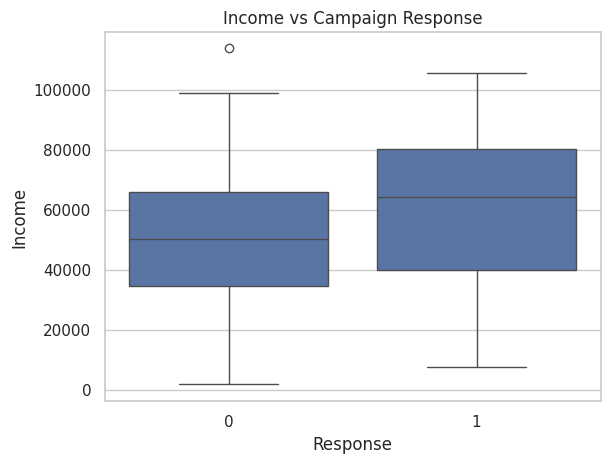

In [29]:
sns.boxplot(x='Response', y='Income', data=df)
plt.title("Income vs Campaign Response")
plt.xlabel("Response")
plt.ylabel("Income")
plt.show()

In [30]:
df.groupby('Response')['Income'].mean()

,Income
Response,
0,50140.325146
1,60192.906752


## Business Insight

Comparing income between responders and non-responders helps identify whether higher-income customers are more likely to accept campaign offers.

# Spending Behaviour

In [31]:
product_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

df['Total_Spending'] = df[product_cols].sum(axis=1)

In [32]:
df.groupby('Response')[['Total_Spending'] + product_cols].mean()

,Total_Spending,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Response,,,,,,,
0,540.021053,272.361988,24.200000,142.533918,35.207602,25.198830,40.518713
1,979.897106,494.154341,38.266881,295.414791,50.778135,38.649518,62.633441


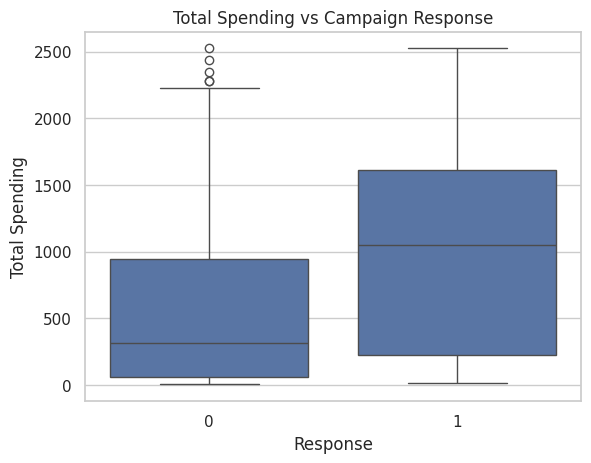

In [33]:
sns.boxplot(x='Response', y='Total_Spending', data=df)
plt.title("Total Spending vs Campaign Response")
plt.xlabel("Response")
plt.ylabel("Total Spending")
plt.show()

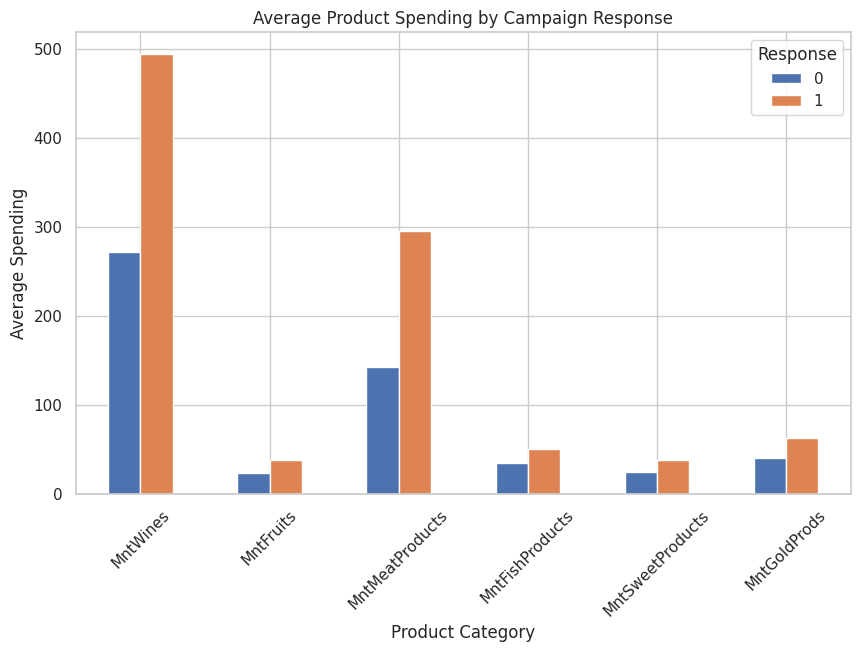

In [34]:
df.groupby('Response')[product_cols].mean().T.plot(kind='bar', figsize=(10,6))
plt.title("Average Product Spending by Campaign Response")
plt.ylabel("Average Spending")
plt.xlabel("Product Category")
plt.xticks(rotation=45)
plt.show()

## Business Insight

Product spending helps identify which customer preferences are associated with higher campaign response.  
Customers with higher spending may represent stronger campaign targets because they already show higher purchase value.

# Purchase Channel Behaviour

In [35]:
channel_cols = [
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth'
]

df.groupby('Response')[channel_cols].mean()

,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
Response,,,,
0,3.944444,2.365497,5.766082,5.346199
1,5.054662,4.180064,6.035370,5.308682


In [ ]:
df.groupby('Response')[channel_cols].mean().T.plot(kind='bar', figsize=(10,6))
plt.title("Average Channel Behavior by Campaign Response")
plt.ylabel("Average Count")
plt.xlabel("Channel Behavior")
plt.xticks(rotation=45)
plt.show()

## Business Insight

Channel behavior shows how customers interact with the company.  
If responders are more active through specific channels, iFood can prioritize those channels for the next campaign.

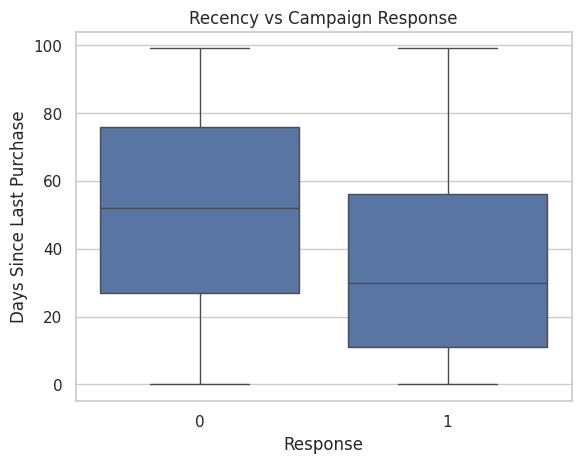

In [36]:
sns.boxplot(x='Response', y='Recency', data=df)
plt.title("Recency vs Campaign Response")
plt.xlabel("Response")
plt.ylabel("Days Since Last Purchase")
plt.show()

In [37]:
df.groupby('Response')['Recency'].mean()

,Recency
Response,
0,51.398246
1,35.038585


## Business Insight

Lower recency means the customer purchased more recently.  
If responders have lower recency, recently active customers should be prioritized in the campaign.

# Campaign History

In [38]:
campaign_cols = [
    'AcceptedCmp1',
    'AcceptedCmp2',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5'
]

df['Previous_Campaign_Acceptance'] = df[campaign_cols].sum(axis=1)

In [39]:
df.groupby('Response')['Previous_Campaign_Acceptance'].mean()

,Previous_Campaign_Acceptance
Response,
0,0.179532
1,0.977492


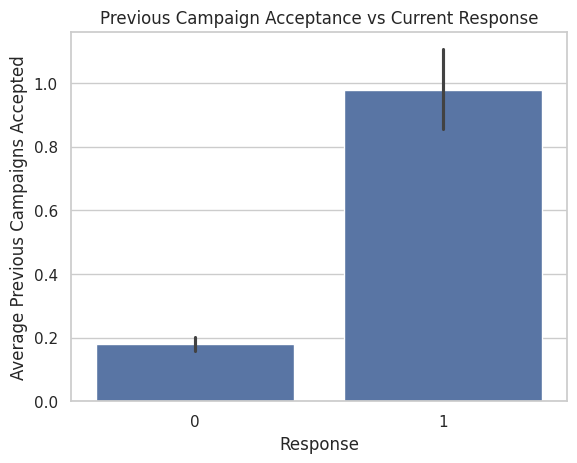

In [40]:
sns.barplot(x='Response', y='Previous_Campaign_Acceptance', data=df)
plt.title("Previous Campaign Acceptance vs Current Response")
plt.xlabel("Response")
plt.ylabel("Average Previous Campaigns Accepted")
plt.show()

# Feature Engineering

In [42]:
# Customer age
# Assuming Year_Birth exists in the dataset

# df['Age'] = 2024 - df['Year_Birth']

In [43]:
# Total number of children/teenagers at home

df['Total_Children'] = df['Kidhome'] + df['Teenhome']

In [44]:
# Total purchases

purchase_cols = [
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases'
]

df['Total_Purchases'] = df[purchase_cols].sum(axis=1)

In [45]:
# Average spending per purchase

df['Avg_Spending_Per_Purchase'] = df['Total_Spending'] / df['Total_Purchases'].replace(0, np.nan)
df['Avg_Spending_Per_Purchase'] = df['Avg_Spending_Per_Purchase'].fillna(0)

In [47]:
# Customer tenure in days

# latest_date = df['DtCustomer'].max()
# df['Customer_Tenure_Days'] = (latest_date - df['DtCustomer']).dt.days

In [49]:
# Check engineered features

df[[
    'Age',
    'Total_Children',
    'Total_Spending',
    'Total_Purchases',
    'Avg_Spending_Per_Purchase',
    'Previous_Campaign_Acceptance'
]].head()

,Age,Total_Children,Total_Spending,Total_Purchases,Avg_Spending_Per_Purchase,Previous_Campaign_Acceptance
0,63,0,1617,25,64.680000,0
1,66,2,27,6,4.500000,0
2,55,0,776,21,36.952381,0
3,36,1,53,8,6.625000,0
4,39,1,422,19,22.210526,0


## Feature Engineering Insight

New features were created to better represent customer value, engagement, family structure, and campaign history.  
These features can improve both segmentation and predictive modeling.

2. **Segmentation**

In [50]:
# Select segmentation features

segment_features = df[[
    'Income',
    'Total_Spending',
    'Recency',
    'Total_Purchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'Total_Children'
]]

In [51]:
# Scale features

scaler = StandardScaler()
scaled_segment_features = scaler.fit_transform(segment_features)

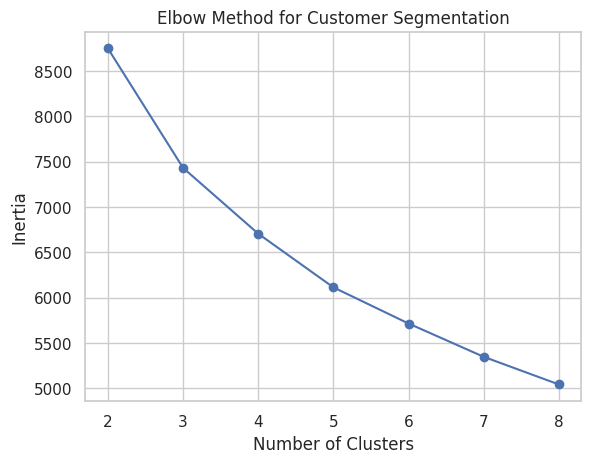

In [52]:
# Elbow method

inertia = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_segment_features)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 9), inertia, marker='o')
plt.title("Elbow Method for Customer Segmentation")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [53]:
# Create final clusters

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Segment'] = kmeans.fit_predict(scaled_segment_features)

In [54]:
# Segment profile

segment_summary = df.groupby('Segment')[[
    'Income',
    'Total_Spending',
    'Recency',
    'Total_Purchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'Total_Children',
    'Response'
]].mean()

segment_summary

,Income,Total_Spending,Recency,Total_Purchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Total_Children,Response
Segment,,,,,,,,,
0,33970.759036,99.753012,24.666667,7.827309,2.080321,0.558233,3.222892,1.162651,0.148594
1,59556.848649,783.589189,47.699099,21.302703,6.742342,3.000000,7.954955,1.117117,0.131532
2,76234.334719,1422.964657,49.162162,21.043659,4.979210,6.380457,8.415800,0.160083,0.303534
3,36590.854209,121.496920,74.710472,8.757700,2.349076,0.683778,3.427105,1.334702,0.036961


In [55]:
# Segment size

df['Segment'].value_counts().sort_index()

,count
Segment,
0,498
1,555
2,481
3,487


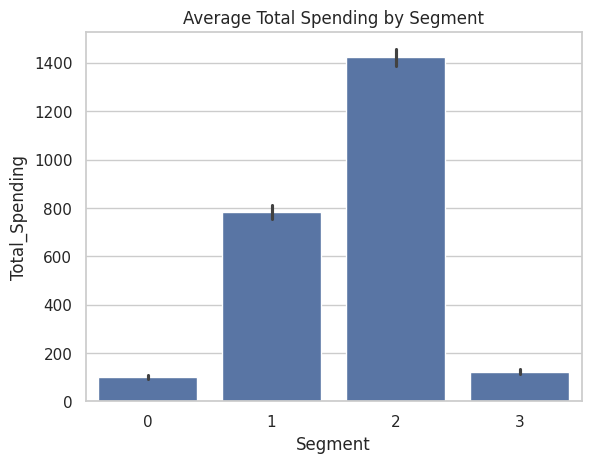

In [56]:
# Visualize segment spending and response

sns.barplot(x='Segment', y='Total_Spending', data=df)
plt.title("Average Total Spending by Segment")
plt.show()

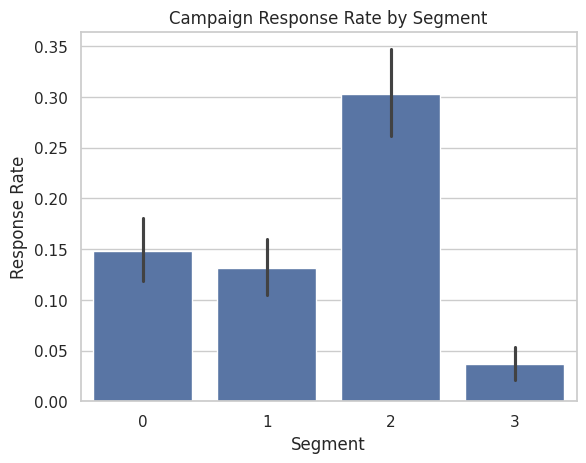

In [57]:
sns.barplot(x='Segment', y='Response', data=df)
plt.title("Campaign Response Rate by Segment")
plt.ylabel("Response Rate")
plt.show()

Business recommendation:

The company should prioritize segments with higher response rates and higher spending potential.  
Low-engagement segments should receive lower-cost reactivation campaigns or be excluded from expensive direct campaigns.

3. **Modeling**

In [58]:
model_df = df.copy()

In [59]:
model_df = model_df.drop(columns=['DtCustomer'], errors='ignore')

In [60]:
# One-hot encode categorical variables

model_df = pd.get_dummies(model_df, drop_first=True)

In [61]:
# Define X and y

X = model_df.drop('Response', axis=1)
y = model_df['Response']

In [62]:
# Train-test split with stratification because the target is imbalanced

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Logistic Regression Model

In [63]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

In [64]:
log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print(classification_report(y_test, log_pred))
print("ROC AUC:", roc_auc_score(y_test, log_prob))
print("Confusion Matrix:")
print(confusion_matrix(y_test, log_pred))

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.95      0.80      0.87       343
           1       0.41      0.74      0.53        62

    accuracy                           0.80       405
   macro avg       0.68      0.77      0.70       405
weighted avg       0.86      0.80      0.82       405

ROC AUC: 0.8634675068183956
Confusion Matrix:
[[276  67]
 [ 16  46]]


# Random Forest Model

In [65]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [66]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print(classification_report(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_prob))
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Results
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       343
           1       0.58      0.23      0.33        62

    accuracy                           0.86       405
   macro avg       0.73      0.60      0.62       405
weighted avg       0.83      0.86      0.83       405

ROC AUC: 0.8791263048998402
Confusion Matrix:
[[333  10]
 [ 48  14]]


# Model Comparison

In [67]:
model_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall': [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1 Score': [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred)
    ],
    'ROC AUC': [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.795062,0.407080,0.741935,0.525714,0.863468
1,Random Forest,0.856790,0.583333,0.225806,0.325581,0.879126


## Modeling Business Insight

Because the response rate is low, accuracy alone is not enough.  
The model should be evaluated using precision, recall, F1 score, and ROC AUC.

The final model should help the company identify customers with a higher probability of accepting the next campaign.

# Feature Imporatance Analysis

In [68]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(15)

,0
Recency,0.077396
Customer_Days,0.074161
AcceptedCmpOverall,0.055080
Previous_Campaign_Acceptance,0.053826
MntGoldProds,0.050230
Total_Spending,0.047337
MntMeatProducts,0.041985
Income,0.040261
Avg_Spending_Per_Purchase,0.040021
MntTotal,0.037272


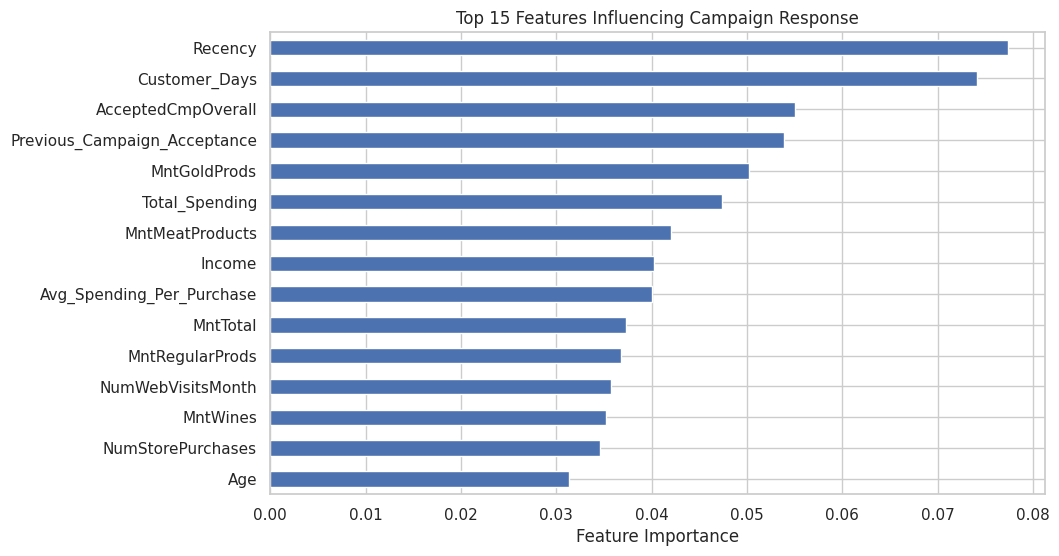

In [69]:
feature_importance.head(15).sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Top 15 Features Influencing Campaign Response")
plt.xlabel("Feature Importance")
plt.show()

## Feature Importance Business Insight

The most important features help explain what drives campaign response.  
These drivers can guide marketing strategy, customer targeting, and campaign personalization.

# Profit Optimization

In [70]:
# Case information

total_campaign_cost = 6720
customers_contacted = 2240
total_campaign_revenue = 3674

cost_per_customer = total_campaign_cost / customers_contacted
num_responders = df['Response'].sum()
revenue_per_responder = total_campaign_revenue / num_responders

cost_per_customer, revenue_per_responder

(3.0, np.float64(11.813504823151126))

In [71]:
# Use Random Forest probabilities for profit targeting

profit_df = pd.DataFrame({
    'actual_response': y_test,
    'predicted_probability': rf_prob
})

profit_df = profit_df.sort_values('predicted_probability', ascending=False)

In [72]:
# Test different probability thresholds

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

results = []

for t in thresholds:
    targeted = profit_df[profit_df['predicted_probability'] >= t]

    customers_targeted = len(targeted)
    responders = targeted['actual_response'].sum()

    revenue = responders * revenue_per_responder
    cost = customers_targeted * cost_per_customer
    profit = revenue - cost

    response_rate_targeted = responders / customers_targeted if customers_targeted > 0 else 0

    results.append([
        t,
        customers_targeted,
        responders,
        response_rate_targeted,
        revenue,
        cost,
        profit
    ])

profit_results = pd.DataFrame(results, columns=[
    'Threshold',
    'Customers_Targeted',
    'Responders',
    'Targeted_Response_Rate',
    'Revenue',
    'Cost',
    'Profit'
])

profit_results

,Threshold,Customers_Targeted,Responders,Targeted_Response_Rate,Revenue,Cost,Profit
0,0.10,187,58,0.310160,685.183280,561.0,124.183280
1,0.15,138,53,0.384058,626.115756,414.0,212.115756
2,0.20,113,49,0.433628,578.861736,339.0,239.861736
3,0.25,91,43,0.472527,507.980707,273.0,234.980707
4,0.30,71,37,0.521127,437.099678,213.0,224.099678
5,0.35,52,30,0.576923,354.405145,156.0,198.405145
6,0.40,37,21,0.567568,248.083601,111.0,137.083601
7,0.50,24,14,0.583333,165.389068,72.0,93.389068


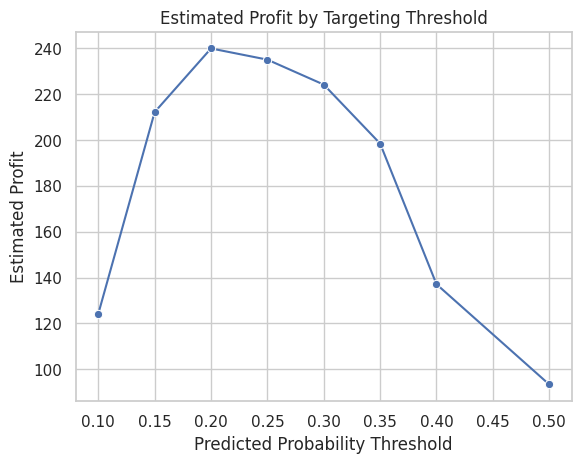

In [73]:
# Visualize profit by threshold

sns.lineplot(x='Threshold', y='Profit', data=profit_results, marker='o')
plt.title("Estimated Profit by Targeting Threshold")
plt.xlabel("Predicted Probability Threshold")
plt.ylabel("Estimated Profit")
plt.show()

In [74]:
# Best threshold

best_threshold = profit_results.sort_values('Profit', ascending=False).head(1)
best_threshold

,Threshold,Customers_Targeted,Responders,Targeted_Response_Rate,Revenue,Cost,Profit
2,0.2,113,49,0.433628,578.861736,339.0,239.861736


## Profit Optimization Insight

Instead of contacting all customers, iFood can target only customers with a high predicted probability of response.

This reduces campaign cost and focuses resources on customers most likely to buy.  
The best threshold should be selected based on the highest estimated profit, not only model accuracy.

Overall Business Recommendations

## 1: Move from mass targeting to selective targeting

The previous campaign had low response and negative profit.  
The company should avoid contacting all customers and instead target customers with higher predicted response probability.

## 2: Prioritize high-value and recently active customers

Customers with stronger spending behavior, lower recency, and higher engagement are more valuable targets.  
These customers are more likely to generate revenue from future campaigns.

## 3: Use customer segmentation for campaign strategy

Each segment should receive a different campaign strategy:

- High-Value Loyal Customers: premium offers and early access campaigns
- Recent Active Buyers: personalized product recommendations
- Discount-Sensitive Customers: controlled promotions and deal-based campaigns
- Low Engagement Customers: lower-cost reactivation campaigns or exclusion from expensive campaigns

## 4: Personalize campaigns using product preferences

If certain product categories are stronger among responders, campaign messages should be personalized based on customer purchase history.

## 5: Use the predictive model before launching campaigns

The model should score customers before each campaign.  
Marketing should focus on customers above the profit-maximizing probability threshold.

## Final Business Overall Insights

By combining customer segmentation with predictive modeling, iFood can reduce wasted campaign spending, improve targeting efficiency, and increase the profitability of future marketing campaigns.

# ==============================
# BEFORE VS AFTER COMPARISON
# ==============================

In [81]:
# Original campaign performance from case
before_customers = 2240
before_cost = 6720
before_revenue = 3674
before_profit = before_revenue - before_cost
before_response_rate = 0.15

# Best model-based strategy from profit_results
best_row = profit_results.sort_values('Profit', ascending=False).iloc[0]

after_threshold = best_row['Threshold']
after_customers = best_row['Customers_Targeted']
after_responders = best_row['Responders']
after_response_rate = best_row['Targeted_Response_Rate']
after_revenue = best_row['Revenue']
after_cost = best_row['Cost']
after_profit = best_row['Profit']

comparison_df = pd.DataFrame({
    'Strategy': ['Before: Contact All Customers', 'After: Model-Based Targeting'],
    'Customers Contacted': [before_customers, after_customers],
    'Response Rate': [before_response_rate, after_response_rate],
    'Revenue': [before_revenue, after_revenue],
    'Cost': [before_cost, after_cost],
    'Profit': [before_profit, after_profit]
})

comparison_df

,Strategy,Customers Contacted,Response Rate,Revenue,Cost,Profit
0,Before: Contact All Customers,2240.0,0.150000,3674.000000,6720.0,-3046.000000
1,After: Model-Based Targeting,113.0,0.433628,578.861736,339.0,239.861736


Profit : Before vs **After**

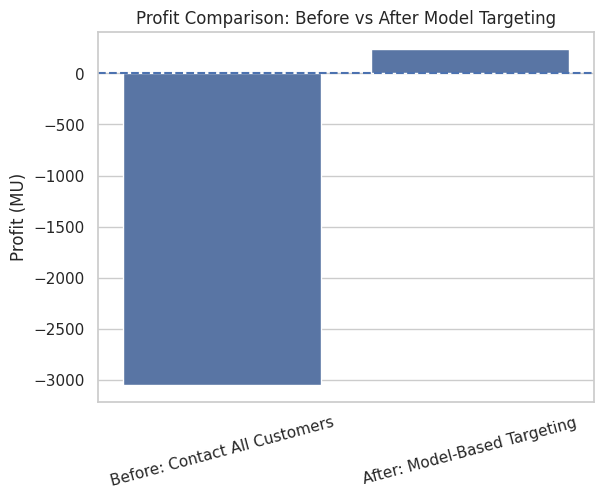

In [77]:
sns.barplot(x='Strategy', y='Profit', data=comparison_df)
plt.title("Profit Comparison: Before vs After Model Targeting")
plt.ylabel("Profit (MU)")
plt.xlabel("")
plt.xticks(rotation=15)
plt.axhline(0, linestyle='--')
plt.show()

Customer Contacted Comparison : Before vs **After**

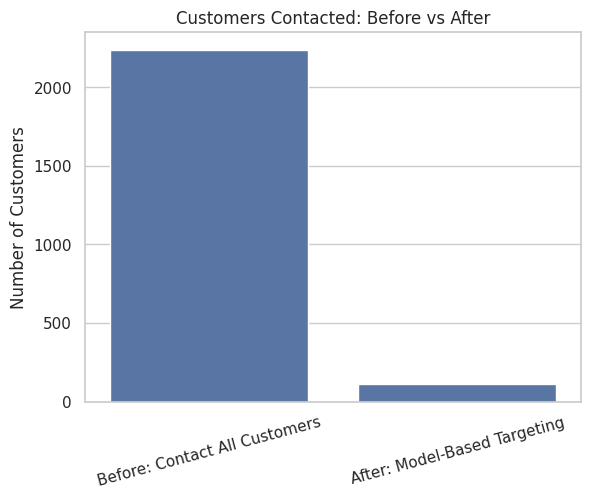

In [79]:
sns.barplot(x='Strategy', y='Customers Contacted', data=comparison_df)
plt.title("Customers Contacted: Before vs After")
plt.ylabel("Number of Customers")
plt.xlabel("")
plt.xticks(rotation=15)
plt.show()

Response Rate : Before vs **After**

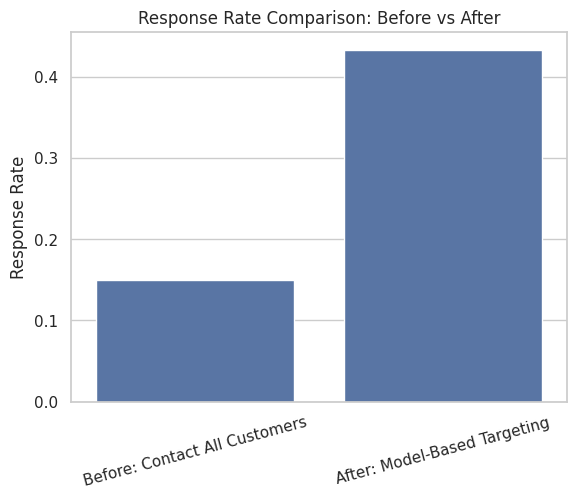

In [78]:
sns.barplot(x='Strategy', y='Response Rate', data=comparison_df)
plt.title("Response Rate Comparison: Before vs After")
plt.ylabel("Response Rate")
plt.xlabel("")
plt.xticks(rotation=15)
plt.show()

Revenue, Cost, Profit Compariso : Before vs **After**

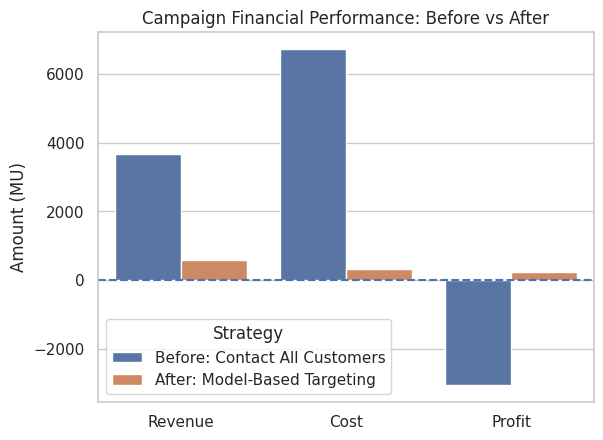

In [80]:
comparison_melted = comparison_df.melt(
    id_vars='Strategy',
    value_vars=['Revenue', 'Cost', 'Profit'],
    var_name='Metric',
    value_name='Value'
)

sns.barplot(x='Metric', y='Value', hue='Strategy', data=comparison_melted)
plt.title("Campaign Financial Performance: Before vs After")
plt.ylabel("Amount (MU)")
plt.xlabel("")
plt.axhline(0, linestyle='--')
plt.show()

## Before vs After Business Insight

The original campaign contacted all 2,240 customers and produced a negative profit.  
After applying model-based targeting, the company contacts fewer customers but focuses on customers with a higher probability of responding.

This improves campaign efficiency by reducing unnecessary marketing costs and increasing the response rate among targeted customers.  
The best targeting threshold is selected based on estimated profit, not only prediction accuracy.

Overall, the model supports a shift from mass marketing to data-driven customer targeting.